# Predicting Student Performance — Part B: Modeling & Evaluation
**Author:** Bidhan Khadka

**Goal:** Train regression models to predict **G3** (final grade) and evaluate them with **MSE** and **R²**.

## 0. Setup

In [1]:
# Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

RANDOM_STATE = 42  # same seed as Part A -> reproducible results
sns.set_theme(style="whitegrid")

## 1. Load Data
Load the preprocessed data from Part A (`processed_data.csv`). If Part A's file is not available yet, fall back to
loading the raw `student-mat.csv` and one-hot encoding the categorical columns with `pd.get_dummies(drop_first=True)`
(the same encoding Part A uses), so this notebook runs on its own.

In [2]:
# Load processed data (from Part A) or fall back to raw data + one-hot encoding
if os.path.exists("processed_data.csv"):
    df = pd.read_csv("processed_data.csv")
    print("Loaded processed_data.csv from Part A")
else:
    raw = pd.read_csv("student-mat.csv", sep=";")  # file is semicolon-separated
    # Convert categorical (text) columns to 0/1 dummy columns; drop_first avoids redundant columns
    df = pd.get_dummies(raw, drop_first=True, dtype=int)
    print("processed_data.csv not found -> loaded student-mat.csv and one-hot encoded it")

print("Shape:", df.shape)
df.head()

processed_data.csv not found -> loaded student-mat.csv and one-hot encoded it
Shape: (395, 42)


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,1,0,1,0,0,0,1,1,0,0
1,17,1,1,1,2,0,5,3,3,1,...,0,0,0,1,0,0,0,1,1,0
2,15,1,1,1,2,3,4,3,2,2,...,1,0,1,0,1,0,1,1,1,0
3,15,4,2,1,3,0,3,2,2,1,...,1,0,0,1,1,1,1,1,1,1
4,16,3,3,1,2,0,4,3,2,1,...,0,0,0,1,1,0,1,1,0,0


## 2. Define Features & Target — Two Feature Sets
- **Set 1:** all features **including** G1 and G2
- **Set 2:** all features **excluding** G1 and G2 (harder — predicts from background factors only)

_Why compare?_ G1/G2 are strongly correlated with G3, so we want to see how much the model depends on them.

In [3]:
# Target variable: final grade G3 (0-20)
y = df["G3"]

# Set 1: every feature except the target (includes period grades G1, G2)
X_with = df.drop(columns=["G3"])

# Set 2: also remove G1 and G2 -> predict using only background/behavioral factors
X_without = df.drop(columns=["G1", "G2", "G3"])

print("Features with G1/G2:   ", X_with.shape[1])
print("Features without G1/G2:", X_without.shape[1])

Features with G1/G2:    41
Features without G1/G2: 39


## 3. Train/Test Split (80/20)
80% of students are used for training and 20% are held out for testing. The same `random_state` is used for both
feature sets, so they use **exactly the same students** in train and test, making the comparison fair.

In [4]:
# 80/20 split; same random_state -> identical rows in both feature sets
X_train_w, X_test_w, y_train, y_test = train_test_split(
    X_with, y, test_size=0.2, random_state=RANDOM_STATE)
X_train_wo, X_test_wo, _, _ = train_test_split(
    X_without, y, test_size=0.2, random_state=RANDOM_STATE)

print("Training set:", X_train_w.shape[0], "students")
print("Test set:    ", X_test_w.shape[0], "students")

Training set: 316 students
Test set:     79 students


## 4. Model 1 — Linear Regression
Linear Regression is sensitive to feature scale (e.g. `absences` ranges 0–75 while most features are 0/1 or 1–5), so
we standardize features with `StandardScaler` (mean 0, std 1).

**Important:** the scaler is fit on the **training data only** and then applied to the test data. Fitting on the full
dataset would leak information about the test set into training.

In [5]:
# Scaling: fit on training data only, then transform both train and test
scaler_w = StandardScaler().fit(X_train_w)
X_train_w_s, X_test_w_s = scaler_w.transform(X_train_w), scaler_w.transform(X_test_w)

scaler_wo = StandardScaler().fit(X_train_wo)
X_train_wo_s, X_test_wo_s = scaler_wo.transform(X_train_wo), scaler_wo.transform(X_test_wo)

In [6]:
# Linear Regression — with G1/G2
lr_w = LinearRegression().fit(X_train_w_s, y_train)
pred_lr_w = lr_w.predict(X_test_w_s)

In [7]:
# Linear Regression — without G1/G2
lr_wo = LinearRegression().fit(X_train_wo_s, y_train)
pred_lr_wo = lr_wo.predict(X_test_wo_s)

## 5. Model 2 — Random Forest
A Random Forest averages many decision trees, each trained on a random sample of students and features. It can
capture non-linear relationships and interactions. Trees split on thresholds, so **scaling is not needed**.

In [8]:
# Random Forest — with G1/G2 (200 trees, fixed seed for reproducibility)
rf_w = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
rf_w.fit(X_train_w, y_train)
pred_rf_w = rf_w.predict(X_test_w)

In [9]:
# Random Forest — without G1/G2
rf_wo = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
rf_wo.fit(X_train_wo, y_train)
pred_rf_wo = rf_wo.predict(X_test_wo)

## 6. Evaluation — MSE & R²
- **MSE (Mean Squared Error):** average squared difference between actual and predicted grade (lower is better).
  **RMSE** is its square root, which is in grade points and easier to interpret.
- **R² score:** proportion of the variance in G3 explained by the model (1.0 = perfect, 0 = no better than always
  predicting the average grade).

In [10]:
def evaluate(model_name, feature_set, y_true, y_pred):
    """Return a dict of evaluation metrics for one model."""
    mse = mean_squared_error(y_true, y_pred)
    return {"Model": model_name, "Features": feature_set,
            "MSE": mse, "RMSE": np.sqrt(mse), "R²": r2_score(y_true, y_pred)}

results = pd.DataFrame([
    evaluate("Linear Regression", "with G1/G2",    y_test, pred_lr_w),
    evaluate("Linear Regression", "without G1/G2", y_test, pred_lr_wo),
    evaluate("Random Forest",     "with G1/G2",    y_test, pred_rf_w),
    evaluate("Random Forest",     "without G1/G2", y_test, pred_rf_wo),
])
results.round(3)

,Model,Features,MSE,RMSE,R²
0,Linear Regression,with G1/G2,5.657,2.378,0.724
1,Linear Regression,without G1/G2,17.604,4.196,0.141
2,Random Forest,with G1/G2,3.868,1.967,0.811
3,Random Forest,without G1/G2,14.969,3.869,0.270


### 6.1 Cross-Validation (robustness check)
With only 395 students, the test set has just 79 students, so the score can change a lot depending on which students
land in it. 5-fold cross-validation trains and tests 5 times on different splits and averages the R².

In [11]:
# 5-fold cross-validated R² (scaler is inside the pipeline, so it is re-fit on each training fold -> no leakage)
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
models = {
    "Linear Regression": make_pipeline(StandardScaler(), LinearRegression()),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
}
cv_rows = []
for name, model in models.items():
    for feat_name, X in [("with G1/G2", X_with), ("without G1/G2", X_without)]:
        scores = cross_val_score(model, X, y, cv=kf, scoring="r2")
        cv_rows.append({"Model": name, "Features": feat_name,
                        "CV R² mean": scores.mean(), "CV R² std": scores.std()})
pd.DataFrame(cv_rows).round(3)

,Model,Features,CV R² mean,CV R² std
0,Linear Regression,with G1/G2,0.792,0.042
1,Linear Regression,without G1/G2,0.026,0.151
2,Random Forest,with G1/G2,0.872,0.056
3,Random Forest,without G1/G2,0.286,0.043


**Observations:**

- **Random Forest with G1/G2 performs best:** test R² = **0.811**, MSE = **3.87** (RMSE ≈ **1.97** grade points on a
  0–20 scale). Linear Regression with G1/G2 is close behind at R² = **0.724**, MSE = **5.66**.
- **Removing G1/G2 causes a large drop:** R² falls to **0.270** (Random Forest) and **0.141** (Linear Regression), with
  RMSE around **3.9–4.2** points. Background factors alone (family, study time, going out, etc.) explain only a small
  part of the final grade.
- **Cross-validation confirms the ranking:** mean 5-fold R² is **0.872** (RF, with G1/G2), **0.792** (LR, with G1/G2),
  **0.286** (RF, without) and **0.026** (LR, without). The high standard deviation for LR without G1/G2 (**±0.151**)
  shows that model is unstable, since its score depends heavily on which students are in the test set.
- Random Forest beats Linear Regression in both settings, which suggests the relationships are partly **non-linear**
  (e.g. the jump from a normal grade to 0).

## 7. Model-Based Feature Importance (Random Forest)
Random Forest measures how much each feature reduces prediction error across all tree splits. This complements the
correlation analysis in Part A.

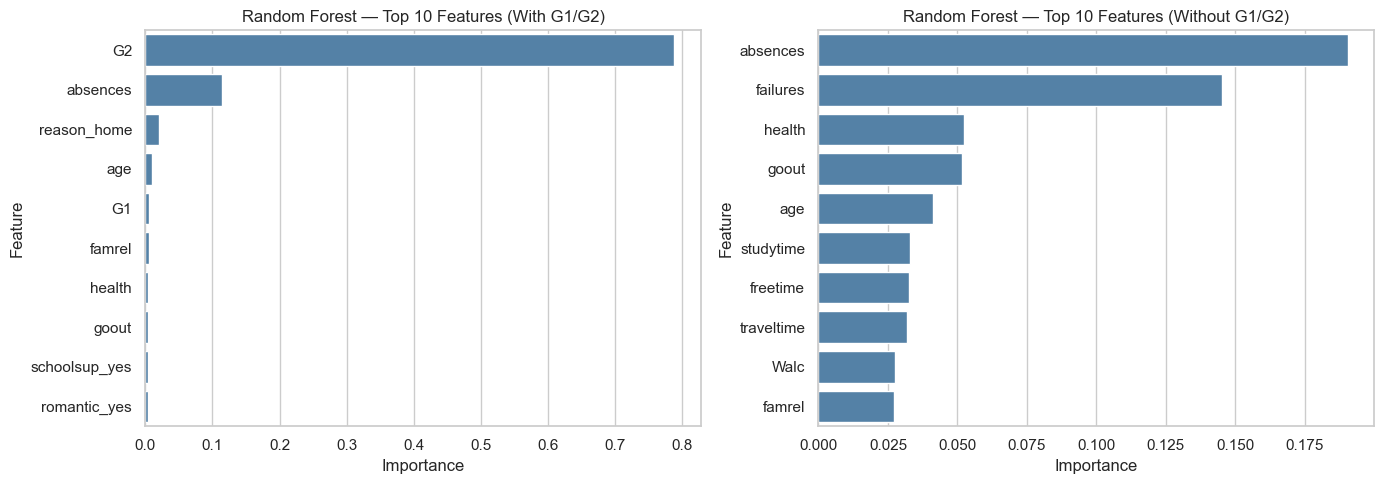

In [12]:
# Top 10 feature importances for both Random Forest models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, model, X, title in [(axes[0], rf_w, X_with, "With G1/G2"),
                            (axes[1], rf_wo, X_without, "Without G1/G2")]:
    imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
    sns.barplot(x=imp.values, y=imp.index, ax=ax, color="steelblue")
    ax.set_title(f"Random Forest — Top 10 Features ({title})")
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

**Observations:**

- **With G1/G2:** `G2` dominates with an importance of about **0.79**. The second-period grade is by far the best
  predictor of the final grade. `G1` ranks low only because it carries almost the same information as `G2` (they are
  highly correlated), so the trees rarely need it once `G2` is used.
- **Without G1/G2:** `absences` (≈ 0.19) and `failures` (≈ 0.15) are the most important, followed by `health`,
  `goout`, `age` and `studytime`. Past failures are a well-known predictor of low grades.
- **Why is `absences` so high?** In this dataset, **all 38 students with G3 = 0 have 0 recorded absences** (the average
  for everyone else is about 6.3). These zeros most likely mean the student dropped out or did not take the final exam,
  not that they attended perfectly. The model uses "0 absences" as a signal for a possible 0 grade, which is a data
  quirk rather than a real behavioral effect.

## 8. Actual vs. Predicted Grades
Each point is one test-set student. Points on the dashed **y = x** line are perfect predictions; the farther a point is
from the line, the larger the error. Students with an actual G3 of 0 are highlighted in red.

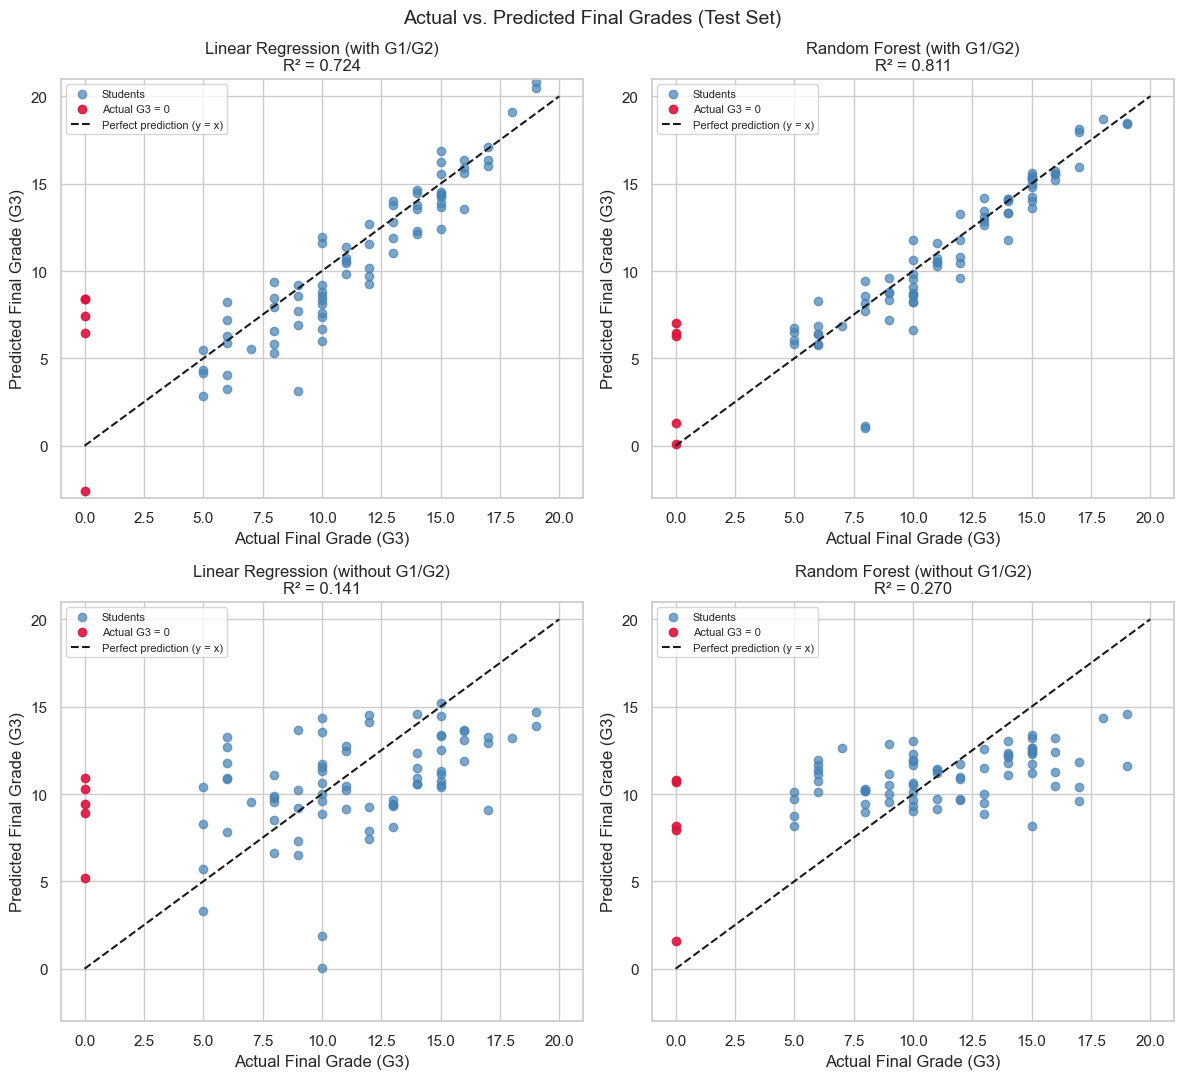

In [13]:
# Actual vs. Predicted: one panel per model/feature-set combination
preds = [("Linear Regression", "with G1/G2", pred_lr_w),
         ("Random Forest", "with G1/G2", pred_rf_w),
         ("Linear Regression", "without G1/G2", pred_lr_wo),
         ("Random Forest", "without G1/G2", pred_rf_wo)]

fig, axes = plt.subplots(2, 2, figsize=(12, 11))
zero = (y_test == 0).values  # students whose actual final grade is 0

for ax, (name, feats, pred) in zip(axes.ravel(), preds):
    ax.scatter(y_test[~zero], pred[~zero], alpha=0.7, color="steelblue", label="Students")
    ax.scatter(y_test[zero], pred[zero], alpha=0.9, color="crimson", label="Actual G3 = 0")
    ax.plot([0, 20], [0, 20], "k--", label="Perfect prediction (y = x)")
    ax.set_xlim(-1, 21); ax.set_ylim(-3, 21)
    ax.set_title(f"{name} ({feats})\nR² = {r2_score(y_test, pred):.3f}")
    ax.set_xlabel("Actual Final Grade (G3)")
    ax.set_ylabel("Predicted Final Grade (G3)")
    ax.legend(loc="upper left", fontsize=8)

plt.suptitle("Actual vs. Predicted Final Grades (Test Set)", fontsize=14)
plt.tight_layout()
plt.show()

**Observations:**

- **With G1/G2 (top row):** most points lie close to the y = x line, especially for Random Forest, which has a tighter
  cloud than Linear Regression. Linear Regression can also predict impossible values (one prediction is about **−2.5**,
  another slightly above **20**) because it is not bounded to the 0–20 range. Random Forest predictions always stay
  within the range seen in training.
- **Without G1/G2 (bottom row):** predictions cluster around **10–12** regardless of the actual grade. The models
  mostly predict "an average student", so good students are under-predicted and weak students are over-predicted. This
  is what a low R² looks like.
- **Students with G3 = 0 (red):** these are the largest errors in every panel. There are 5 in the test set. Random
  Forest with G1/G2 correctly predicts close to 0 for two of them (one already had G2 = 0; the other had a normal G2 of 7
  but was flagged by other features such as 0 absences), but predicts about 6–7 for the others, whose G1/G2 were normal (7–10) before their final grade dropped to 0.
- **Reverse error:** two students with an actual G3 of 8 are predicted about 1. Both had normal G1/G2 but **0
  absences**, so the model mistook them for dropouts, the same quirk seen in the feature importance.

## 9. Discussion of Results
- **Best model:** Random Forest using all features (including G1/G2): test R² = **0.811**, MSE = **3.87**, CV R² =
  **0.872**. On average its predictions are about **2 grade points** away from the true final grade.
- **Effect of G1/G2:** they are the main source of predictive power. Without them, the best R² is only **0.270**.
  Including them is valid if the goal is to predict the final grade **during** the school year (after the 1st/2nd
  periods). If the goal is to identify at-risk students **before** the year starts, the "without G1/G2" model is the
  realistic one, and its accuracy is limited.
- **Where the model fails:** students who end up with **G3 = 0** (likely dropouts or students who missed the final
  exam). Their earlier grades look normal, so no model can foresee the drop to 0. These 38 students (≈10%) cause most
  of the error.
- **What the metrics mean:** an R² of 0.81 means the model explains about 81% of the variation in final grades. MSE
  weights large errors heavily, so the few G3 = 0 misses noticeably raise it.
- **Test split vs. cross-validation:** the test-set scores differ somewhat from the CV averages (e.g. 0.811 vs 0.872).
  With only 79 test students, one split gives a noisy estimate, so the CV numbers are more reliable.

## 10. Challenges & Conclusion (for slides)
**Challenges:**
- **Deciding whether to use G1/G2:** they make prediction much easier but may not be available in a real early-warning
  setting, so we trained and compared both versions.
- **Zero final grades:** 38 students have G3 = 0, likely dropouts rather than real exam scores. They create outliers
  the models cannot predict and a misleading pattern (0 absences ↔ 0 grade).
- **Small dataset:** only 395 students (79 in the test set), so results vary with the train/test split. We added 5-fold
  cross-validation to get a more stable estimate.
- **Many categorical features:** one-hot encoding increased the feature count from 32 to 41 input features.
- **Technical:** a NumPy 2.0 / macOS numerical-library issue caused false warnings in Linear Regression. It was solved by
  pinning NumPy 1.26 (see `requirements.txt`).

**Conclusion:**
- Random Forest predicted final math grades with **R² = 0.811** (test) / **0.872** (CV) when earlier period grades were
  available, within the 0.6–0.85 range suggested for reasonable performance.
- Prior academic performance (**G2**) is by far the strongest predictor. Without it, factors such as **absences**,
  **past failures**, health and social life explain only about **27%** of the variance.
- Future work: treat G3 = 0 students separately (e.g. a classification model for dropout risk), tune Random Forest
  hyperparameters, and try gradient boosting.

## References
- Cortez, P. & Silva, A. (2008). *Using Data Mining to Predict Secondary School Student Performance.* In Proceedings of
  5th FUture BUsiness TEChnology Conference. Dataset: UCI Machine Learning Repository,
  https://archive.ics.uci.edu/ml/datasets/Student+Performance
- Libraries: pandas, NumPy, matplotlib, seaborn, scikit-learn (Pedregosa et al., 2011)
- _Add any other resources used (and AI tool use, if required by the course policy)_